# Cu Nanoparticles formation in LDPE

## Set_up()

In [1]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi

✓ Workspace ready


## Data

##### Cu 0.5%

In [2]:
path = r'E:\Nps Cu\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

path = r'E:\Nps Cu\CuPE_0_5perc_1_4m_aftertrans\CuPE_0_5perc_1_4m_aftertrans_RT_measurement'
Cu_05_after = BM26_experiment(path)

##### Cu 3%

In [3]:
path = r'E:\Nps Cu\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\CuPE_3perc_1_4m_aftertrans\CuPE_3perc_1_4m_aftertrans_RT_measurement'
Cu_3_after = BM26_experiment(path)

## Functions

In [4]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm(data):
    q = data['q']
    I = data['I']
    
    left = 28
    right = 28.8
    Q_norm = np.trapz(I[(q>left)*(q<right)], x = q[(q>left)*(q<right)])
    
    data['I']/=Q_norm

def norm_saxs(q, I):
    I /= np.mean(I[(q>3)*(q<4)])

# Analysis

##### XRD phases

In [5]:
lmbda = 1.5406e-1
# theta_array_Cu = [43.34, 50.46, 74.14, 89.93,]
# theta_array_Cu2O = [36.33, 42.21, 61.28, ]
# theta_array_CuO = [ 38.86, 39.11, 48.92, 58.47, 61.7, 66.06]

theta_array_Cu = [43.34,  50.46]
theta_array_CuO = [ 38.86, ]
theta_array_Cu2O = [36.33, ]

q_array_Cu = 4*pi/lmbda*np.sin(np.deg2rad(np.array(theta_array_Cu)/2))
q_array_Cu2O = 4*pi/lmbda*np.sin(np.deg2rad(np.array(theta_array_Cu2O)/2))
q_array_CuO = 4*pi/lmbda*np.sin(np.deg2rad(np.array(theta_array_CuO)/2))

##### Cu 0.5% 

In [6]:
Time_05_heat = Cu_05_heat.get_Time_profile()
Temp_05_heat = Cu_05_heat.get_T_profile()

Time_05_iso = Cu_05_iso.get_Time_profile() + Time_05_heat[-1]
Temp_05_iso = Cu_05_iso.get_T_profile()


Found 88 EDF files in SAXS
Found 66 EDF files in SAXS


Text(0, 0.5, 'Temperature')

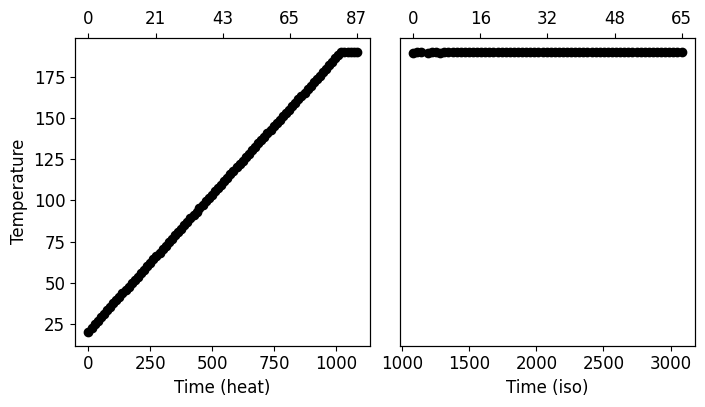

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
scatter1 = ax1.scatter(Time_05_heat, Temp_05_heat, color='black')
scatter2 = ax2.scatter(Time_05_iso, Temp_05_iso, color='black')

ax1_top = ax1.twiny()
ax2_top = ax2.twiny()

frames_heat = np.arange(len(Time_05_heat))
frames_iso = np.arange(len(Time_05_iso))

ax1_top.set_xlim(ax1.get_xlim())
ax2_top.set_xlim(ax2.get_xlim())

ax1_top.set_xticks(np.linspace(Time_05_heat[0], Time_05_heat[-1], 5))
ax1_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_05_heat)-1, 5)])

ax2_top.set_xticks(np.linspace(Time_05_iso[0], Time_05_iso[-1], 5))
ax2_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_05_iso)-1, 5)])

plt.subplots_adjust(wspace=0.1)


ax1.tick_params(right=False)
ax2.tick_params(left=False)

ax1.set_xlabel('Time (heat)')
ax2.set_xlabel('Time (iso)')
ax1.set_ylabel('Temperature')

##### Cu 3%

In [8]:
Time_3_heat = Cu_3_heat.get_Time_profile()
Temp_3_heat = Cu_3_heat.get_T_profile()

Time_3_iso = Cu_3_iso.get_Time_profile() + Time_3_heat[-1]
Temp_3_iso = Cu_3_iso.get_T_profile()


Found 89 EDF files in SAXS
Found 60 EDF files in SAXS


Text(0, 0.5, 'Temperature')

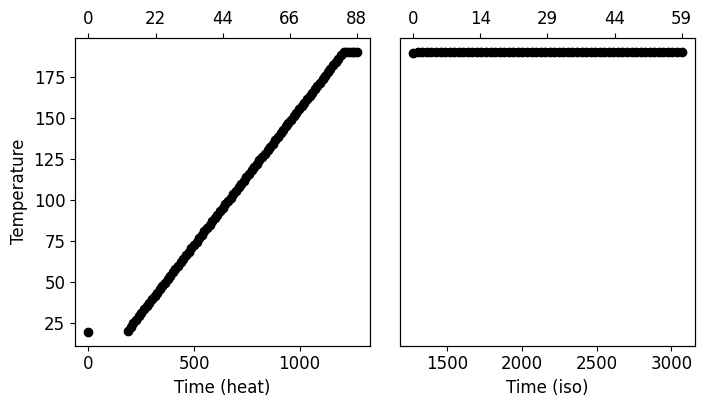

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
scatter1 = ax1.scatter(Time_3_heat, Temp_3_heat, color='black')
scatter2 = ax2.scatter(Time_3_iso, Temp_3_iso, color='black')

ax1_top = ax1.twiny()
ax2_top = ax2.twiny()

frames_heat = np.arange(len(Time_3_heat))
frames_iso = np.arange(len(Time_3_iso))

ax1_top.set_xlim(ax1.get_xlim())
ax2_top.set_xlim(ax2.get_xlim())

ax1_top.set_xticks(np.linspace(Time_3_heat[0], Time_3_heat[-1], 5))
ax1_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_3_heat)-1, 5)])

ax2_top.set_xticks(np.linspace(Time_3_iso[0], Time_3_iso[-1], 5))
ax2_top.set_xticklabels([f'{int(i)}' for i in np.linspace(0, len(Time_3_iso)-1, 5)])

plt.subplots_adjust(wspace=0.1)


ax1.tick_params(right=False)
ax2.tick_params(left=False)

ax1.set_xlabel('Time (heat)')
ax2.set_xlabel('Time (iso)')
ax1.set_ylabel('Temperature')

##### SAXS Analysis

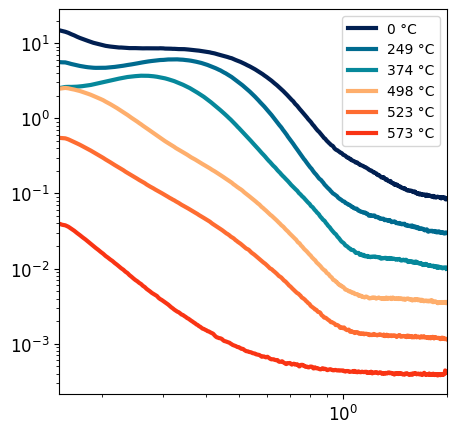

In [11]:
plt.figure(figsize=(5,5))

index = [0,  20,  30, 40, 42,  46]
colors = ['#011f51','#006b8f','#06889b','#feae6c','#fe6c31','#f93414']
coef = [1, 1/3, 1/9, 1/27, 1/81, 1/243, 1/64, 1/128]
width = 3

k = 0
for i in index:
    q, I = Cu_05_heat.get_1d_SAXS(i)
    #norm_saxs(q_saxs, I)
    plt.plot(q, I*coef[k], 
             label=str(Time_05_heat[i])+' °C', 
             linewidth=width, 
             color=colors[k]
            )
    k += 1
plt.xlim(.15, 2)
plt.semilogx()
plt.semilogy()
plt.legend(fontsize=10)
plt.show()

[]

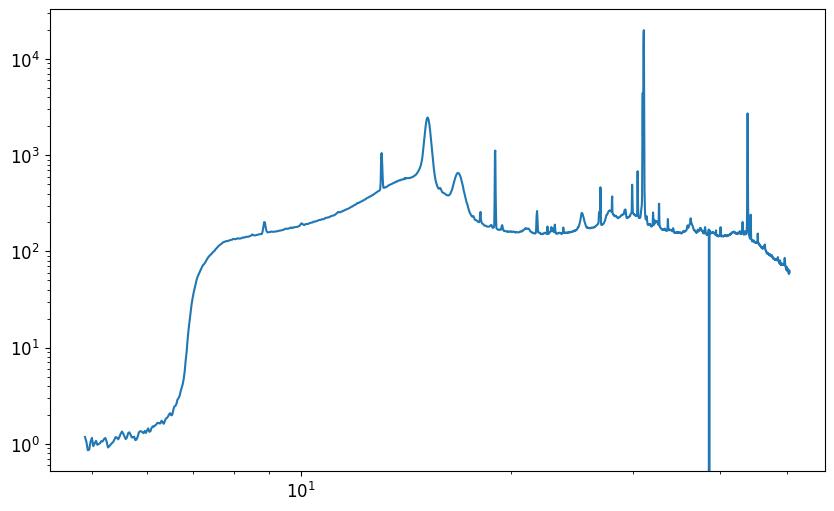

In [33]:
q, I = Cu_05_heat.get_1d_WAXS()
plt.plot(q, I)
plt.semilogy()
plt.semilogx()

In [31]:
q[39]

np.float64(0.12715503758812358)

##### XRD analysis


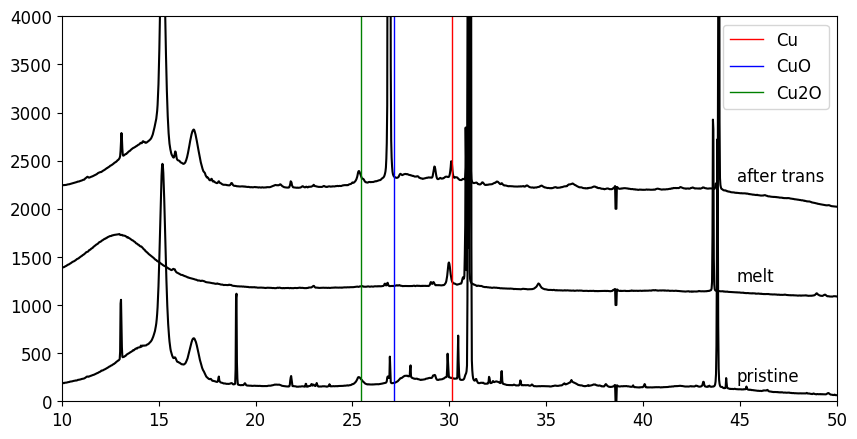

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

q, I = Cu_05_heat.get_1d_WAXS(0)
plt.plot(q, I, color='black')

q, I = Cu_05_iso.get_1d_WAXS(50)
plt.plot(q, I + 1000, color='black')

q, I = Cu_05_after.get_1d_WAXS(5)
plt.plot(q, I + 2000, color='black')



plt.ylim(0, 4000)
plt.xlim(10, 50)

# ax.axvline(x=q_array_Cu[0], color='red', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_CuO[2], color='blue', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_Cu2O[0], color='green', linewidth=1, label='Cu' )

for hkl in q_array_Cu:
    ax.axvline(x=hkl, color='red', linewidth=1, label='Cu' )

for hkl in q_array_CuO:
    ax.axvline(x=hkl, color='blue', linewidth=1, label='CuO')

for hkl in q_array_Cu2O:
    ax.axvline(x=hkl, color='green', linewidth=1, label='Cu2O')
    
fig.text(0.8, 0.15, 'pristine' )
fig.text(0.8, 0.35, 'melt' )
fig.text(0.8, 0.55, 'after trans' )

plt.legend()

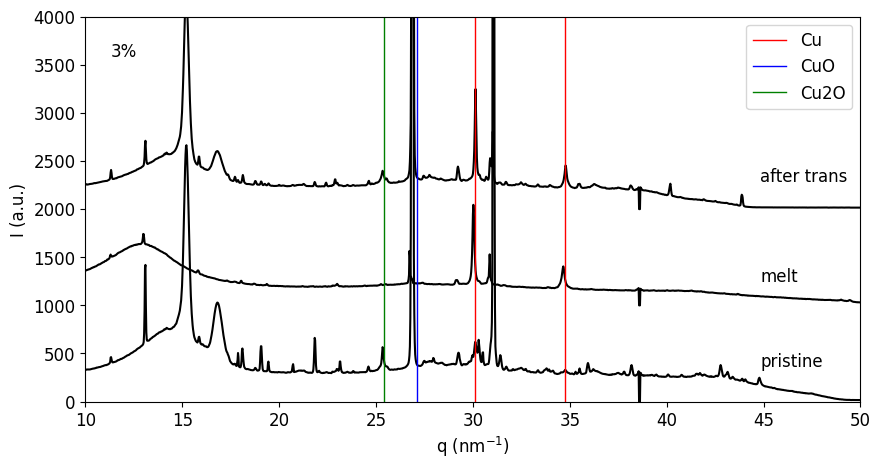

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

q, I = Cu_3_heat.get_1d_WAXS(0)
plt.plot(q, I, color='black')

q, I = Cu_3_iso.get_1d_WAXS(20)
plt.plot(q, I + 1000, color='black')

q, I = Cu_3_after.get_1d_WAXS(1)
plt.plot(q, I + 2000, color='black')



plt.ylim(0, 4000)
plt.xlim(10, 50)

# ax.axvline(x=q_array_Cu[0], color='red', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_CuO[2], color='blue', linewidth=1, label='Cu' )
# ax.axvline(x=q_array_Cu2O[0], color='green', linewidth=1, label='Cu' )

flag = 0
for hkl in q_array_Cu:
    if flag == 0:
        ax.axvline(x=hkl, color='red', linewidth=1, label='Cu' )
        flag += 1
    else:
        ax.axvline(x=hkl, color='red', linewidth=1 )
    
for hkl in q_array_CuO:
    ax.axvline(x=hkl, color='blue', linewidth=1, label='CuO')

for hkl in q_array_Cu2O:
    ax.axvline(x=hkl, color='green', linewidth=1, label='Cu2O')
    
fig.text(0.15, 0.8, '3%' )
fig.text(0.8, 0.18, 'pristine' )
fig.text(0.8, 0.35, 'melt' )
fig.text(0.8, 0.55, 'after trans' )

ax.set_xlabel('q (nm$^{-1}$)')
ax.set_ylabel('I (a.u.)')
plt.legend()